In [ ]:
  !pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install imbalanced-learn
!pip install tensorflow
!pip install shap
!pip install scikit-learn


# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [ ]:
#Importing dataset from google drive
from google.colab import drive
drive.mount('/content/drive')

def load_data(file_path):
  file_path = '/content/drive/My Drive/Cyber security dataset GBP.xlsx'
  df = pd.read_csv(file_path)
  return df

Mounted at /content/drive


In [ ]:
#Preview the dataset

def load_data(file_path):
  df = pd.read_excel(file_path)
  return df

file_path = '/content/drive/My Drive/Cyber security dataset GBP.xlsx'
df = load_data(file_path)

print("Data Preview:")
print(df.head())

Data Preview:
   Country  Year        Attack Type     Target Industry  \
0        2  2019           Phishing           Education   
1        2  2019         Ransomware              Retail   
2        5  2017  Man-in-the-Middle                  IT   
3        8  2024         Ransomware  Telecommunications   
4        4  2018  Man-in-the-Middle                  IT   

   Financial Loss (in Million $)  Number of Affected Users Attack Source  \
0                      84.530039                    773169  Hacker Group   
1                      61.330134                    295961  Hacker Group   
2                      41.153316                    605895  Hacker Group   
3                      47.751436                    659320  Nation-state   
4                      72.667665                    810682       Insider   

  Security Vulnerability Type Defense Mechanism Used  \
0          Unpatched Software                    VPN   
1          Unpatched Software               Firewall   
2     

In [ ]:
# Displaying descriptive statistics of the DataFrame
print("\nData Description:")
print(df.describe())


Data Description:
            Country          Year  Financial Loss (in Million $)  \
count  30000.000000  30000.000000                   30000.000000   
mean       4.512333   2019.570333                      50.467451   
std        2.868122      2.857503                      29.317965   
min        0.000000   2015.000000                       0.442999   
25%        2.000000   2017.000000                      25.292259   
50%        5.000000   2020.000000                      50.075362   
75%        7.000000   2022.000000                      74.794212   
max        9.000000   2024.000000                     129.610151   

       Number of Affected Users  Incident Resolution Time (in Hours)  \
count              30000.000000                         30000.000000   
mean              504684.136333                            36.476000   
std               289900.588647                            20.567682   
min                  424.000000                             1.000000   
25%     

In [ ]:
#Preprocessing (Data Cleaning)

# For numerical columns:
for col in df.select_dtypes(include=np.number).columns:
  if df[col].isnull().any():
    df[col].fillna(df[col].mean(), inplace=True)

# For categorical columns (example: fill NaNs with the mode of the column)
for col in df.select_dtypes(include='object').columns:
  if df[col].isnull().any():
    df[col].fillna(df[col].mode()[0], inplace=True)

# Remove duplicate rows
df.drop_duplicates(inplace=True)


# Display info after cleaning
print("\nData Info After Cleaning:")
df.info()


Data Info After Cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 30 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Country                              30000 non-null  int64  
 1   Year                                 30000 non-null  int64  
 2   Attack Type                          30000 non-null  object 
 3   Target Industry                      30000 non-null  object 
 4   Financial Loss (in Million $)        30000 non-null  float64
 5   Number of Affected Users             30000 non-null  int64  
 6   Attack Source                        30000 non-null  object 
 7   Security Vulnerability Type          30000 non-null  object 
 8   Defense Mechanism Used               30000 non-null  object 
 9   Incident Resolution Time (in Hours)  30000 non-null  int64  
 10  Cyber Maturity Score                 30000 non-null  int64  
 11  C

/tmp/ipython-input-404054874.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [ ]:
# Changing country as number to country names

# Map numerical country codes to country names
country_mapping = {
    1: 'USA',
    2: 'Canada',
    3: 'Mexico',
    4: 'UK',
    5: 'Germany',
    6: 'France',
    7: 'China',
    8: 'India',
    9: 'Japan',
    10: 'Australia',
    # Adding more mappings as needed based on your dataset
}

# Applying the mapping to the 'Country' column (assuming 'Country' is the column name)
# Replace 'Country' with the actual column name in your DataFrame
if 'Country' in df.columns:
    df['Country_Name'] = df['Country'].map(country_mapping)
    # Display the first few rows to verify the new column
    print("\nDataFrame with Country Names:")
    print(df[['Country', 'Country_Name']].head())
else:
    print("\n'Country' column not found in the DataFrame.")


DataFrame with Country Names:
   Country Country_Name
0        2       Canada
1        2       Canada
2        5      Germany
3        8        India
4        4           UK



Cleaned Data Preview:
   Country  Year        Attack Type     Target Industry  \
0        2  2019           Phishing           Education   
1        2  2019         Ransomware              Retail   
2        5  2017  Man-in-the-Middle                  IT   
3        8  2024         Ransomware  Telecommunications   
4        4  2018  Man-in-the-Middle                  IT   

   Financial Loss (in Million $)  Number of Affected Users Attack Source  \
0                      84.530039                    773169  Hacker Group   
1                      61.330134                    295961  Hacker Group   
2                      41.153316                    605895  Hacker Group   
3                      47.751436                    659320  Nation-state   
4                      72.667665                    810682       Insider   

  Security Vulnerability Type Defense Mechanism Used  \
0          Unpatched Software                    VPN   
1          Unpatched Software               Firewall 

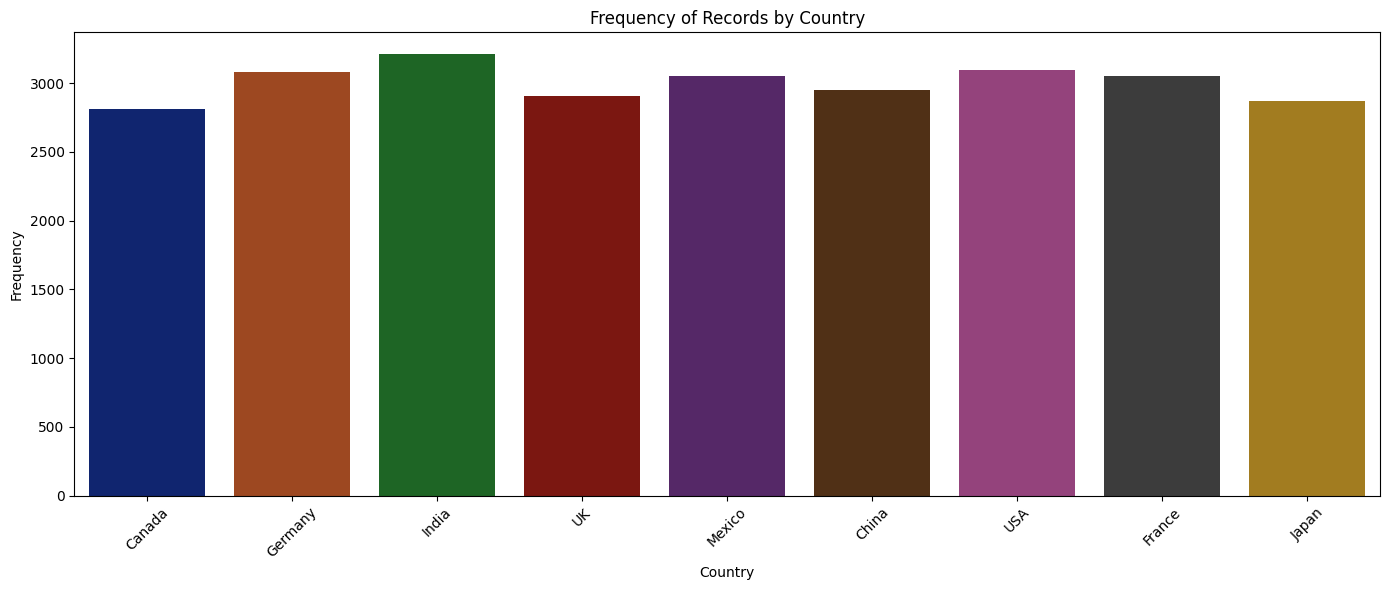

In [ ]:
# Displaying a preview of the cleaned data
print("\nCleaned Data Preview:")
print(df.head())

# Distribution of numerical features.
if 'Country_Name' in df.columns:
    plt.figure(figsize=(14, 6))
    ax = sns.countplot(data=df,
                       x='Country_Name',
                       hue='Country_Name',
                       palette='dark',
                       legend=False)

    # Rotate x-tick labels
    plt.xticks(rotation=45)
    plt.title("Frequency of Records by Country")
    plt.xlabel("Country")
    plt.ylabel("Frequency")

    # Annotate bars
    for p in ax.patches:
        ax.annotate(f'{p.get_height()}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    fontsize=9, color='white', xytext=(0, 5),
                    textcoords='offset points')

    plt.tight_layout()
    plt.show()
else:
    print("'Country_Name' column not found in the dataset.")

Class Distribution Before SMOTE: Counter({'DDoS': 4248, 'Phishing': 4232, 'SQL Injection': 4024, 'Ransomware': 3944, 'Malware': 3880, 'Man-in-the-Middle': 3672})


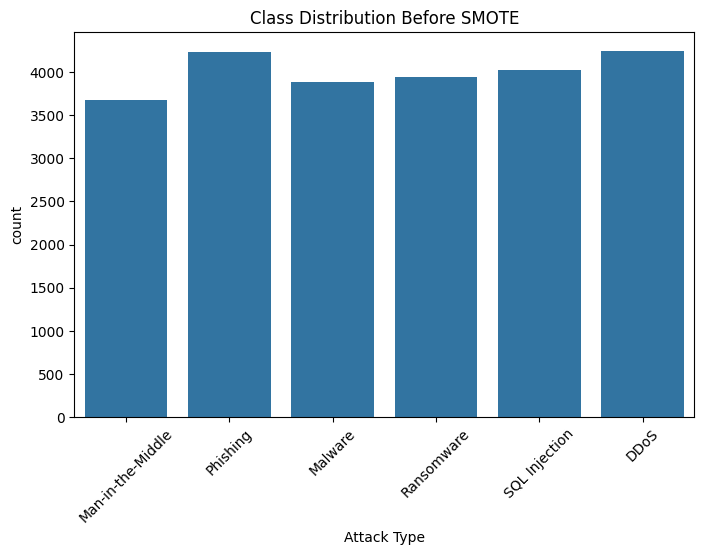

Class Distribution After SMOTE: Counter({'Man-in-the-Middle': 4248, 'Phishing': 4248, 'Malware': 4248, 'Ransomware': 4248, 'SQL Injection': 4248, 'DDoS': 4248})


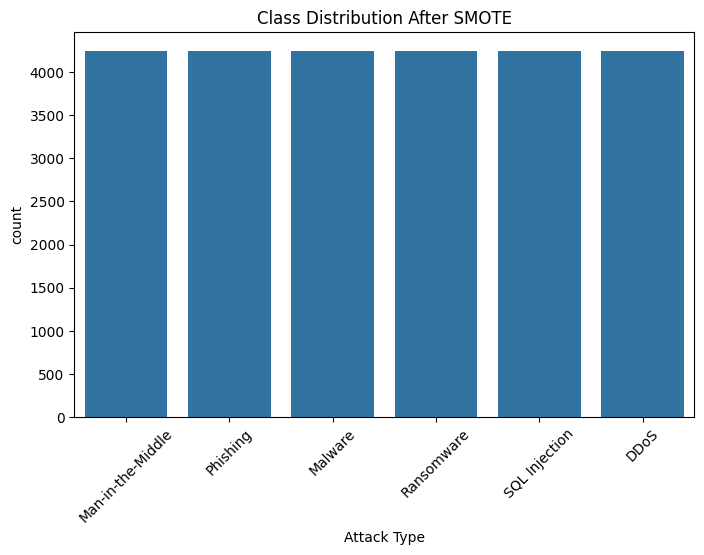

In [ ]:
# Performing SMOTE
# Prepare X and y
if 'Attack Type' in df.columns:
    X = df.drop('Attack Type', axis=1)
    y = df['Attack Type']

    # Identify feature types
    numerical_features = X.select_dtypes(include='number').columns
    categorical_features = X.select_dtypes(include='object').columns

    # Preprocessing
    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Preprocess X_train
    X_train_processed = preprocessor.fit_transform(X_train)

    # Show class distribution BEFORE SMOTE ---
    print("Class Distribution Before SMOTE:", Counter(y_train))
    plt.figure(figsize=(8, 5))
    sns.countplot(x=y_train)
    plt.title("Class Distribution Before SMOTE")
    plt.xticks(rotation=45)
    plt.show()

    # Apply SMOTE ---
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

    # Show class distribution AFTER SMOTE ---
    print("Class Distribution After SMOTE:", Counter(y_train_resampled))
    plt.figure(figsize=(8, 5))
    sns.countplot(x=y_train_resampled)
    plt.title("Class Distribution After SMOTE")
    plt.xticks(rotation=45)
    plt.show()

else:
    print("'Attack Type' column not found in dataset.")

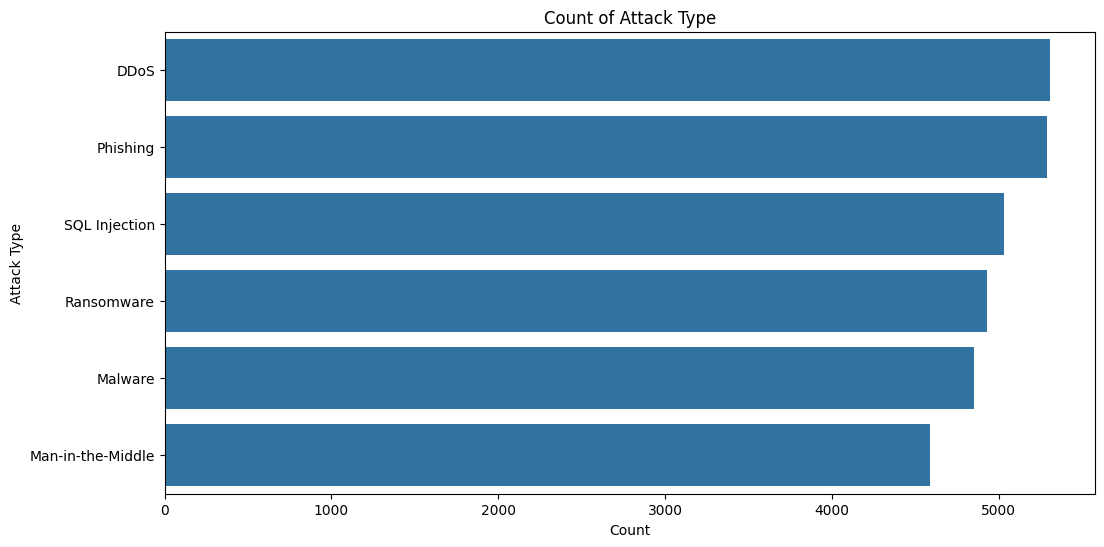

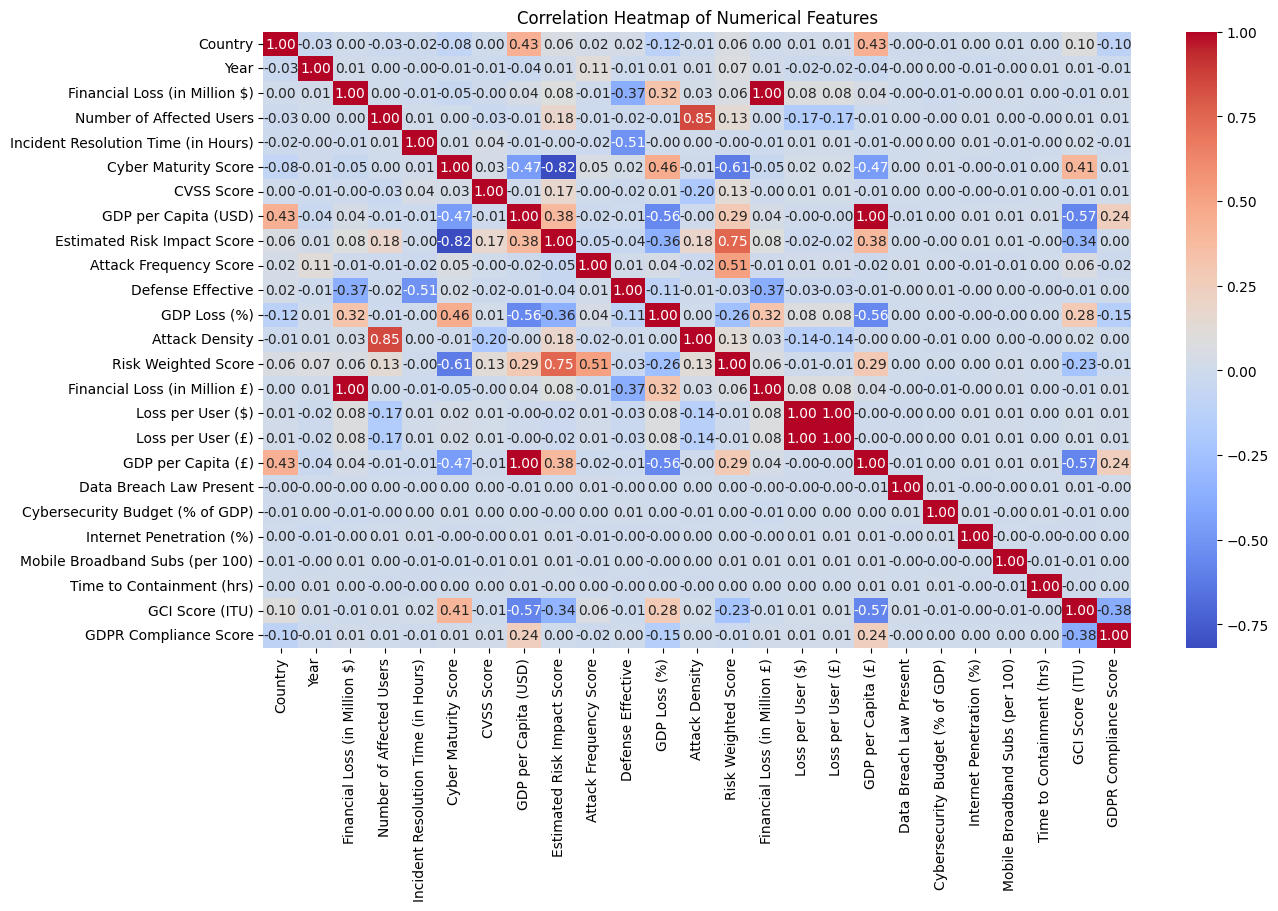

Required columns 'Country Name' and 'Attack Type' not found for 'Count of Attack Types by Country' plot.


In [ ]:
# Visualizing the frequency of categories in categorical features
if len(df.select_dtypes(include='object').columns) > 0:
    categorical_col = df.select_dtypes(include='object').columns[0]
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df, y=categorical_col, order = df[categorical_col].value_counts().index)
    plt.title(f'Count of {categorical_col}')
    plt.xlabel('Count')
    plt.ylabel(categorical_col)
    plt.show()


# Correlation Heatmap: Visualizing the correlation matrix between numerical features.
if len(df.select_dtypes(include=np.number).columns) > 1:
    plt.figure(figsize=(14, 8))
    sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Heatmap of Numerical Features')
    plt.show(

#Count of Attack Types by Country (Grouped Bar Plot)
# This plot shows how the distribution of attack types varies across different countries.
if 'Country Name' in df.columns and 'Attack Type' in df.columns:
    plt.figure(figsize=(15, 8))
    sns.countplot(data=df, y='Country Name', hue='Attack Type', order = df['Country Name'].value_counts().index)
    plt.title('Count of Attack Types by Country')
    plt.xlabel('Count')
    plt.ylabel('Country')
    plt.legend(title='Attack Type')
    plt.show()
else:
    print("Required columns 'Country Name' and 'Attack Type' not found for 'Count of Attack Types by Country' plot.")

Required columns 'Country Name', 'Loss per User (£)', and 'GDP per Capita (£)' not found for 'Average Loss per User vs. GDP per Capita' plot.


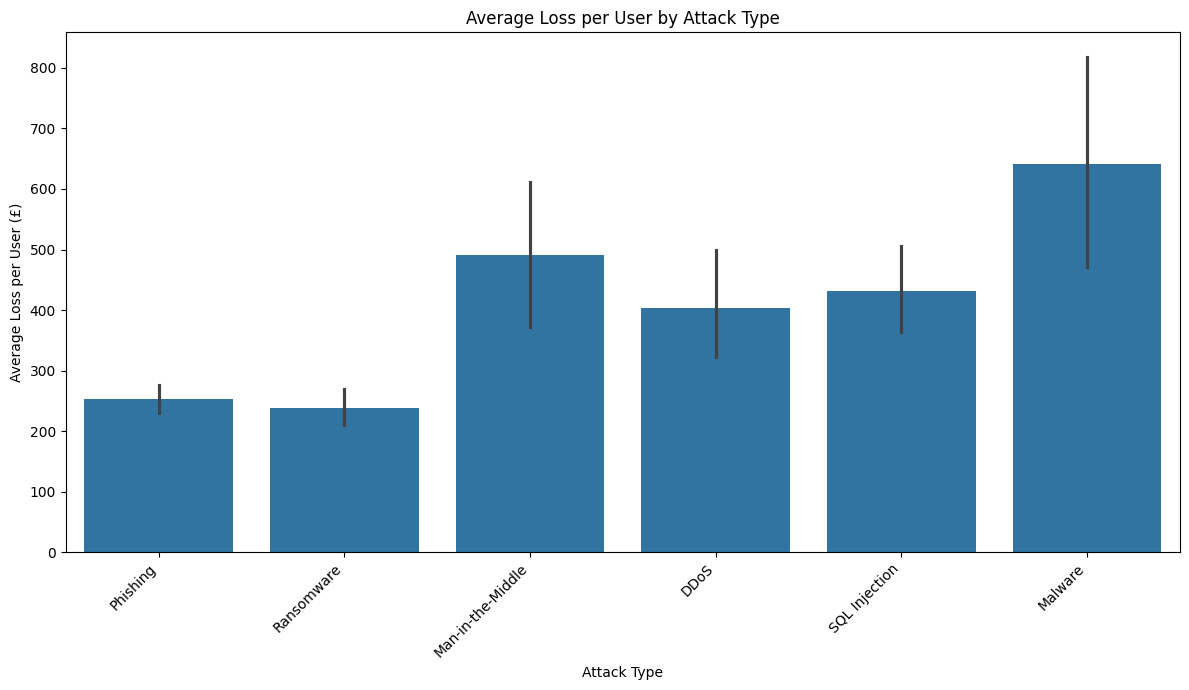

Required columns 'Country Name' and 'GDP per Capita (£)' not found for 'Average GDP per Capita by Country' plot.


In [ ]:
# Average Loss per User vs. GDP per Capita by Country
# Relationship between economic indicators (GDP per capita) and the financial impact of attacks (Loss per User)
# across different countries.
if 'Country Name' in df.columns and 'Loss per User (£)' in df.columns and 'GDP per Capita (£)' in df.columns:
    # Calculate average 'Loss per User (£)' and 'GDP per Capita (£)' for each country
    country_agg = df.groupby('Country Name').agg({
        'Loss per User (£)': 'mean',
        'GDP per Capita (£)': 'mean'
    }).reset_index()

    plt.figure(figsize=(12, 8))
    sns.scatterplot(data=country_agg, x='GDP per Capita (£)', y='Loss per User (£)', hue='Country Name', s=100) # s controls marker size
    plt.title('Average Loss per User vs. GDP per Capita by Country')
    plt.xlabel('Average GDP per Capita (£)')
    plt.ylabel('Average Loss per User (£)')
    plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.show()
else:
     print("Required columns 'Country Name', 'Loss per User (£)', and 'GDP per Capita (£)' not found for 'Average Loss per User vs. GDP per Capita' plot.")

# Average Loss per User by Attack Type (Bar Plot)
# This plot shows the average financial impact of different types of attacks.
if 'Attack Type' in df.columns and 'Loss per User (£)' in df.columns:
    plt.figure(figsize=(12, 7))
    sns.barplot(data=df, x='Attack Type', y='Loss per User (£)', estimator=np.mean)
    plt.title('Average Loss per User by Attack Type')
    plt.xlabel('Attack Type')
    plt.ylabel('Average Loss per User (£)')
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
    plt.tight_layout() # Adjust layout to prevent labels overlapping
    plt.show()
else:
    print("Required columns 'Attack Type' and 'Loss per User (£)' not found for 'Average Loss per User by Attack Type' plot.")

# Average GDP per Capita by Country (Bar Plot)
if 'Country Name' in df.columns and 'GDP per Capita (£)' in df.columns:
    plt.figure(figsize=(12, 7))
    sns.barplot(data=df, x='Country Name', y='GDP per Capita (£)', estimator=np.mean)
    plt.title('Average GDP per Capita by Country')
    plt.xlabel('Country')
    plt.ylabel('Average GDP per Capita (£)')
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
    plt.tight_layout()
    plt.show()
else:
    print("Required columns 'Country Name' and 'GDP per Capita (£)' not found for 'Average GDP per Capita by Country' plot.")

Training Gradient Boosting Classifier...
Training complete.

Gradient Boosting Classifier Model Evaluation:
Confusion Matrix:
 [[608  80  63 130  81 100]
 [135 447  72 143  89  84]
 [ 97  63 429 153  89  87]
 [131  62  49 650  82  84]
 [119  75  56 169 478  89]
 [124  80  52 160 102 488]]

Classification Report:
                    precision    recall  f1-score   support

             DDoS       0.50      0.57      0.53      1062
          Malware       0.55      0.46      0.50       970
Man-in-the-Middle       0.60      0.47      0.52       918
         Phishing       0.46      0.61      0.53      1058
       Ransomware       0.52      0.48      0.50       986
    SQL Injection       0.52      0.49      0.50      1006

         accuracy                           0.52      6000
        macro avg       0.53      0.51      0.52      6000
     weighted avg       0.52      0.52      0.52      6000


Accuracy Score: 0.5166666666666667


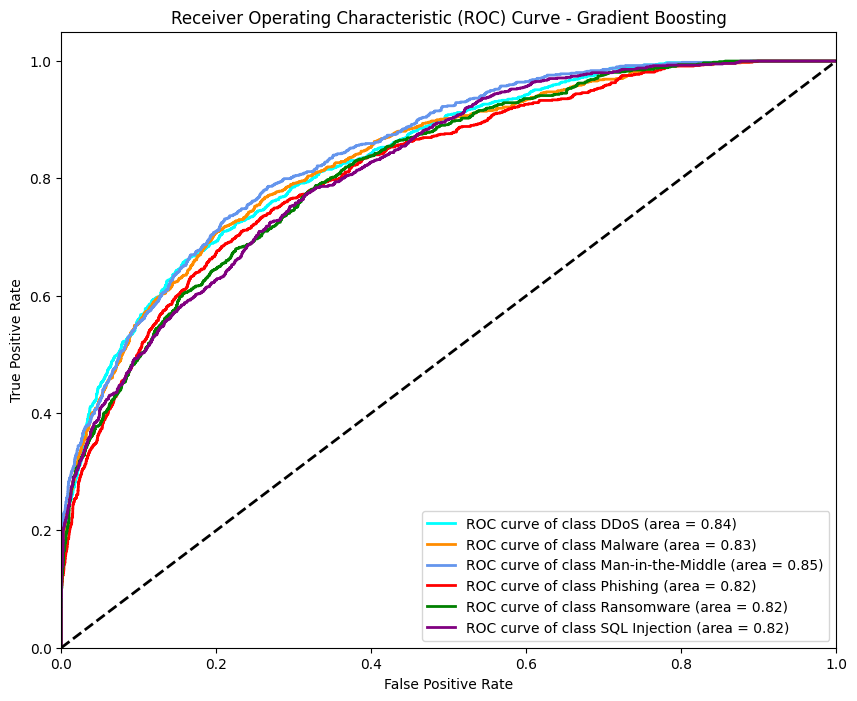

In [ ]:
# Gradient Boosting model pipeline
# You can tune parameters like n_estimators, learning_rate, max_depth, etc.
gb_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42))])

# Train the Gradient Boosting model
print("Training Gradient Boosting Classifier...")
gb_pipeline.fit(X_train, y_train)
print("Training complete.")

# Make predictions on the test set
y_pred_gb = gb_pipeline.predict(X_test)

# Evaluate the Gradient Boosting model
print("\nGradient Boosting Classifier Model Evaluation:")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))
print("\nAccuracy Score:", accuracy_score(y_test, y_pred_gb))

# Optional: Plot ROC Curve for Gradient Boosting (for multi-class, using OvR strategy)
# Requires predicted probabilities
if hasattr(gb_pipeline.named_steps['classifier'], 'predict_proba'):
    y_pred_proba_gb = gb_pipeline.predict_proba(X_test)

    from sklearn.preprocessing import label_binarize
    from sklearn.metrics import roc_curve, auc # Import roc_curve and auc
    from itertools import cycle
    import matplotlib.pyplot as plt
    import numpy as np

    # Binarize the output for multi-class ROC
    if 'y_test' in locals() and 'y' in locals():
        n_classes = len(np.unique(y))
        y_test_bin = label_binarize(y_test, classes=np.unique(y))

        plt.figure(figsize=(10, 8))

        fpr_gb = dict()
        tpr_gb = dict()
        roc_auc_gb = dict()
        for i in range(n_classes):
            fpr_gb[i], tpr_gb[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba_gb[:, i])
            roc_auc_gb[i] = auc(fpr_gb[i], tpr_gb[i])

        # Plot all ROC curves
        colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'purple'])
        for i, color in zip(range(n_classes), colors):
            plt.plot(fpr_gb[i], tpr_gb[i], color=color, lw=2,
                     label='ROC curve of class {0} (area = {1:0.2f})'.format(np.unique(y)[i], roc_auc_gb[i]))

        plt.plot([0, 1], [0, 1], 'k--', lw=2)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic (ROC) Curve - Gradient Boosting')
        plt.legend(loc="lower right")
        plt.show()
    else:
        print("Test data (y_test) or original target variable (y) not found. Cannot plot ROC curve.")
else:
    print("Gradient Boosting classifier does not have predict_proba method. Cannot plot ROC curve.")

PermutationExplainer explainer: 6001it [14:34,  6.81it/s]
/tmp/ipython-input-2977119109.py:23: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, class_index_to_visualize], X_test_transformed, feature_names=feature_names, class_names=gb_model.classes_)


Generating SHAP summary plot for class: DDoS


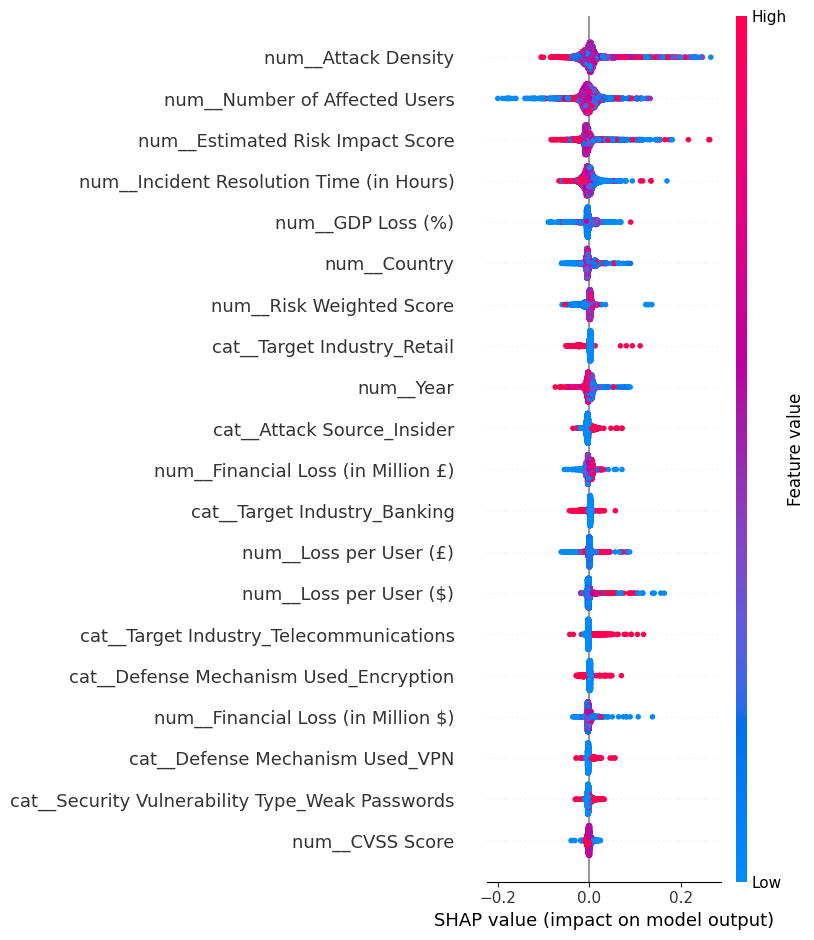

In [ ]:
# Get the trained model from the pipeline
gb_model = gb_pipeline.named_steps['classifier']

# Transform the test data using the same preprocessor
X_test_transformed = preprocessor.transform(X_test)

# Get feature names from the preprocessor
feature_names = preprocessor.get_feature_names_out()

# Initialize SHAP explainer for multi-class models
# Explain predictions for each class
explainer = shap.Explainer(gb_model.predict_proba, X_test_transformed, feature_names=feature_names)

# Compute SHAP values
# shap_values is a list of arrays, one for each class
shap_values = explainer(X_test_transformed)

# Summary plot for the first class (you can change the index to visualize other classes)
class_index_to_visualize = 0
class_name_to_visualize = gb_model.classes_[class_index_to_visualize]

print(f"Generating SHAP summary plot for class: {class_name_to_visualize}")
shap.summary_plot(shap_values[:, :, class_index_to_visualize], X_test_transformed, feature_names=feature_names, class_names=gb_model.classes_)


K-Nearest Neighbors (KNN) Model Evaluation:
Confusion Matrix:
 [[977  13  16  19  21  16]
 [ 44 852  22  21  14  17]
 [ 50  31 789  18  17  13]
 [ 48  34  41 893  21  21]
 [ 38  33  31  29 838  17]
 [ 39  32  37  42  31 825]]

Classification Report:
                    precision    recall  f1-score   support

             DDoS       0.82      0.92      0.87      1062
          Malware       0.86      0.88      0.87       970
Man-in-the-Middle       0.84      0.86      0.85       918
         Phishing       0.87      0.84      0.86      1058
       Ransomware       0.89      0.85      0.87       986
    SQL Injection       0.91      0.82      0.86      1006

         accuracy                           0.86      6000
        macro avg       0.86      0.86      0.86      6000
     weighted avg       0.86      0.86      0.86      6000


Accuracy Score: 0.8623333333333333


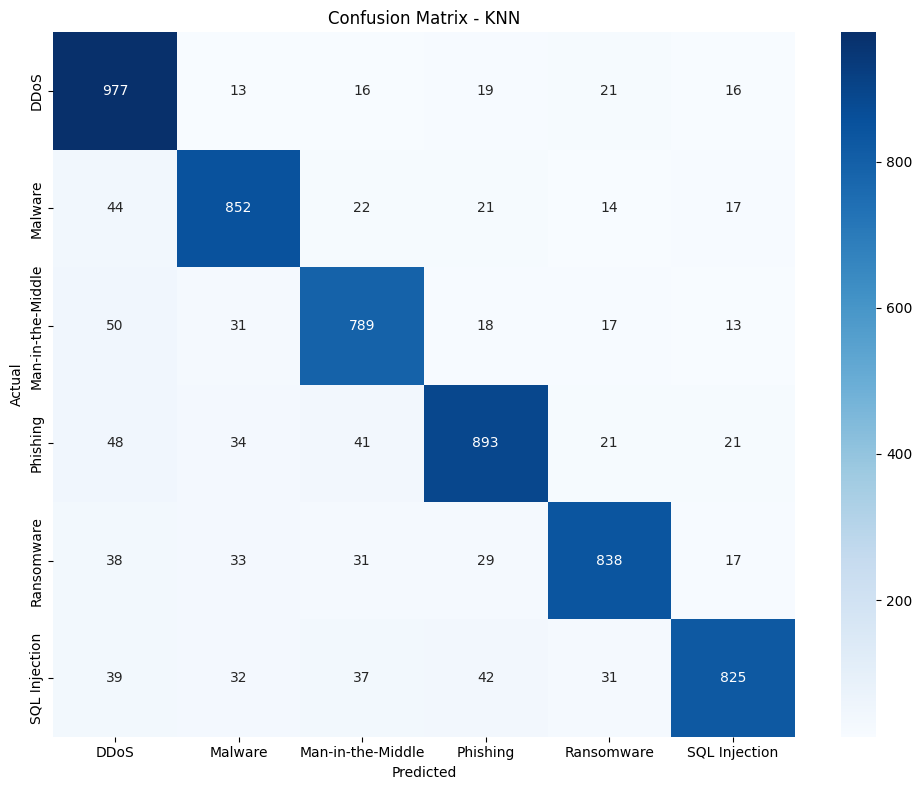

In [ ]:
# Using KNN model to predict the attack type
if 'Attack Type' in df.columns:
    X = df.drop('Attack Type', axis=1)
    y = df['Attack Type']

    # Identify numerical and categorical columns
    numerical_features = X.select_dtypes(include=np.number).columns
    categorical_features = X.select_dtypes(include='object').columns

    # Create preprocessing pipelines
    numerical_transformer = StandardScaler()
    categorical_transformer = OneHotEncoder(handle_unknown='ignore')

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numerical_transformer, numerical_features),
            ('cat', categorical_transformer, categorical_features)
        ]
    )

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Fit and transform the training data
    X_train_processed = preprocessor.fit_transform(X_train)
    X_test_processed = preprocessor.transform(X_test)

    # Create and train the KNN model
    knn_pipeline = Pipeline(steps=[
        ('classifier', KNeighborsClassifier(n_neighbors=5))
    ])
    knn_pipeline.fit(X_train_processed, y_train)

    # Make predictions
    y_pred_knn = knn_pipeline.predict(X_test_processed)

    # Evaluate the KNN model
    print("\nK-Nearest Neighbors (KNN) Model Evaluation:")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
    print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))
    print("\nAccuracy Score:", accuracy_score(y_test, y_pred_knn))

    # Plot the confusion matrix
    cm = confusion_matrix(y_test, y_pred_knn)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.title("Confusion Matrix - KNN")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

else:
    print("\n'Attack Type' column not found. Cannot perform KNN classification without a target variable.")

In [ ]:
# Final Performance Summary
# ANSI escape code for bold
BOLD = "\033[1m"
END = "\033[0m"

print(f"{BOLD} Final Model Performance Summary{END}")
print(f"{BOLD} Gradient Boosting Classifier:{END}")
print(f"{BOLD} - Before Accuracy Score:{END} {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"{BOLD} - Classification Report:{END}")
print(classification_report(y_test, y_pred_gb))

print(f"\n{BOLD} K-Nearest Neighbors (KNN):{END}")
print(f"{BOLD} - Accuracy Score:{END} {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"{BOLD} - Classification Report:{END}")
print(classification_report(y_test, y_pred_knn))

 Final Model Performance Summary
 Gradient Boosting Classifier:
 - Before Accuracy Score: 0.5167
 - Classification Report:
                   precision    recall  f1-score   support

             DDoS       0.50      0.57      0.53      1062
          Malware       0.55      0.46      0.50       970
Man-in-the-Middle       0.60      0.47      0.52       918
         Phishing       0.46      0.61      0.53      1058
       Ransomware       0.52      0.48      0.50       986
    SQL Injection       0.52      0.49      0.50      1006

         accuracy                           0.52      6000
        macro avg       0.53      0.51      0.52      6000
     weighted avg       0.52      0.52      0.52      6000


 K-Nearest Neighbors (KNN):
 - Accuracy Score: 0.8623
 - Classification Report:
                   precision    recall  f1-score   support

             DDoS       0.82      0.92      0.87      1062
          Malware       0.86      0.88      0.87       970
Man-in-the-Middle       0